In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True

print("Using device:", device)


Using device: cuda


In [3]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import datasets, transforms
from torchvision.models import resnet18, resnet50
from tqdm import tqdm
import matplotlib.pyplot as plt


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [5]:
mnist_train_full = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

mnist_test_official = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 36.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.08MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.74MB/s]


In [6]:
from torch.utils.data import ConcatDataset

full_dataset = ConcatDataset([mnist_train_full, mnist_test_official])

total = len(full_dataset)  # 70000
train_size = int(0.7 * total)  # 49000
val_size = int(0.1 * total)    # 7000
test_size = total - train_size - val_size  # 14000

mnist_train, mnist_val, mnist_test = random_split(
    full_dataset, [train_size, val_size, test_size]
)
print("Train:", len(mnist_train))
print("Val:", len(mnist_val)) 
print("Test:", len(mnist_test))

Train: 49000
Val: 7000
Test: 14000


In [7]:
def get_loaders(batch_size, pin_memory=True):
    train_loader = DataLoader(
        mnist_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=pin_memory
    )

    val_loader = DataLoader(
        mnist_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory
    )

    test_loader = DataLoader(
        mnist_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory
    )

    return train_loader, val_loader, test_loader


In [8]:
def get_model(model_name):
    if model_name == "resnet18":
        model = resnet18(pretrained=False)
    elif model_name == "resnet50":
        model = resnet50(pretrained=False)
    else:
        raise ValueError("Invalid model name")

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)


In [9]:
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    correct, total, loss_sum = 0, 0, 0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    return loss_sum / len(loader), 100 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    correct, total, loss_sum = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out = model(x)
                loss = criterion(out, y)

            loss_sum += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), 100 * correct / total


def test(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return 100 * correct / total


/tmp/ipykernel_55/2533370566.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


with batch size 16 and learning rate 0.001

In [28]:
batch_size = 16
optimizer_name = "SGD"
learning_rate = 0.001
epochs = 2
pin_memory = False
model_name = "resnet18"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/2] | Train Acc: 90.69% | Val Acc: 98.36%


Epoch [2/2] | Train Acc: 98.22% | Val Acc: 98.64%
TEST ACCURACY: 98.71428571428571
Model saved at: mnist_resnet18_bs16_SGD_lr0.001.pth


Batch size learning 0.0001

In [29]:
batch_size = 16
optimizer_name = "SGD"
learning_rate = 0.0001
epochs = 2
pin_memory = False
model_name = "resnet18"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/2] | Train Acc: 65.24% | Val Acc: 87.73%


Epoch [2/2] | Train Acc: 93.01% | Val Acc: 95.06%
TEST ACCURACY: 95.37142857142857
Model saved at: mnist_resnet18_bs16_SGD_lr0.0001.pth


In [30]:
batch_size = 16
optimizer_name = "Adam"
learning_rate = 0.001
epochs = 2
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/2] | Train Acc: 96.07% | Val Acc: 98.73%


Epoch [2/2] | Train Acc: 98.26% | Val Acc: 97.69%
TEST ACCURACY: 97.79285714285714
Model saved at: mnist_resnet18_bs16_Adam_lr0.001.pth


In [31]:
batch_size = 16
optimizer_name = "Adam"
learning_rate = 0.0001
epochs = 2
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/2] | Train Acc: 96.32% | Val Acc: 97.44%


Epoch [2/2] | Train Acc: 98.71% | Val Acc: 98.69%
TEST ACCURACY: 98.75
Model saved at: mnist_resnet18_bs16_Adam_lr0.0001.pth


In [32]:
batch_size = 32
optimizer_name = "SGD"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 87.59% | Val Acc: 97.31%


Epoch [2/3] | Train Acc: 97.85% | Val Acc: 98.04%


Epoch [3/3] | Train Acc: 98.55% | Val Acc: 98.89%
TEST ACCURACY: 98.85
Model saved at: mnist_resnet18_bs32_SGD_lr0.001.pth


In [33]:
batch_size = 32
optimizer_name = "SGD"
learning_rate = 0.0001
epochs = 2
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/2] | Train Acc: 50.56% | Val Acc: 74.00%


Epoch [2/2] | Train Acc: 84.00% | Val Acc: 89.57%
TEST ACCURACY: 89.47142857142858
Model saved at: mnist_resnet18_bs32_SGD_lr0.0001.pth


In [34]:
batch_size = 32
optimizer_name = "SGD"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 50.68% | Val Acc: 71.91%


Epoch [2/3] | Train Acc: 83.26% | Val Acc: 91.39%


Epoch [3/3] | Train Acc: 92.44% | Val Acc: 94.41%
TEST ACCURACY: 94.55
Model saved at: mnist_resnet18_bs32_SGD_lr0.0001.pth


In [35]:
batch_size = 32
optimizer_name = "Adam"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 96.36% | Val Acc: 98.70%


Epoch [2/3] | Train Acc: 98.55% | Val Acc: 99.03%


Epoch [3/3] | Train Acc: 98.82% | Val Acc: 98.81%
TEST ACCURACY: 98.80714285714286
Model saved at: mnist_resnet18_bs32_Adam_lr0.001.pth


In [11]:
batch_size = 32
optimizer_name = "Adam"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)


train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 96.33% | Val Acc: 98.20%


Epoch [2/3] | Train Acc: 98.85% | Val Acc: 98.81%


Epoch [3/3] | Train Acc: 99.14% | Val Acc: 99.19%
TEST ACCURACY: 99.2
Model saved at: mnist_resnet18_bs32_Adam_lr0.0001.pth


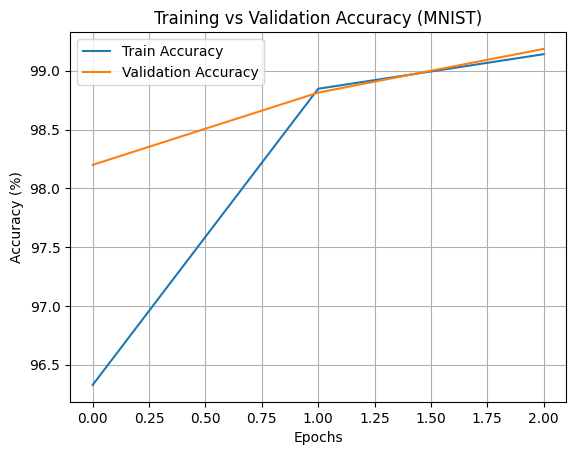

In [12]:
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy (MNIST_resnet_50_batch_32)")
plt.legend()
plt.grid(True)
plt.show()

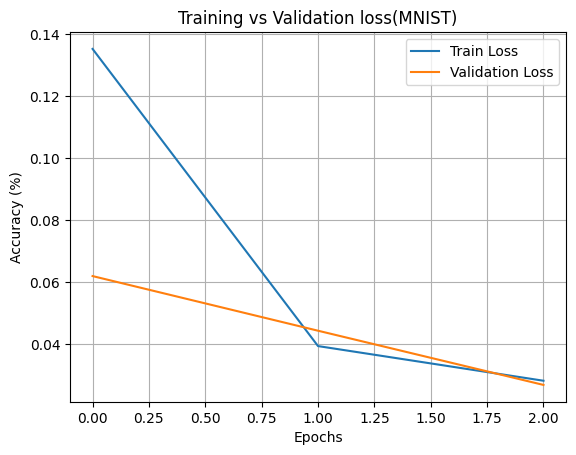

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation loss(MNIST)")
plt.legend()
plt.grid(True)
plt.show()


Fashion mnist


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # REQUIRED for ResNet
    transforms.ToTensor()
])


In [29]:
from torchvision import datasets

fashion_train_full = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

fashion_test_official = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)


In [30]:
from torch.utils.data import ConcatDataset

fashion_full = ConcatDataset([
    fashion_train_full,
    fashion_test_official
])

print("Total images:", len(fashion_full))  # 70000


Total images: 70000


In [31]:
total = len(fashion_full)  # 70000

train_size = int(0.7 * total)   # 49000
val_size   = int(0.1 * total)   # 7000
test_size  = total - train_size - val_size  # 14000

fashion_train, fashion_val, fashion_test = random_split(
    fashion_full, [train_size, val_size, test_size]
)

print("Train:", len(fashion_train))
print("Val:", len(fashion_val))
print("Test:", len(fashion_test))


Train: 49000
Val: 7000
Test: 14000


In [32]:
from torch.utils.data import DataLoader

def get_fashion_loaders(batch_size, pin_memory=True):
    train_loader = DataLoader(
        fashion_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,      # Kaggle safe
        pin_memory=pin_memory
    )

    val_loader = DataLoader(
        fashion_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory
    )

    test_loader = DataLoader(
        fashion_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory
    )

    return train_loader, val_loader, test_loader


In [33]:
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    correct, total, loss_sum = 0, 0, 0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item()
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    return loss_sum / len(loader), 100 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    correct, total, loss_sum = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out = model(x)
                loss = criterion(out, y)

            loss_sum += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), 100 * correct / total


def test(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

    return 100 * correct / total


/tmp/ipykernel_55/2533370566.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [34]:
import torch.nn as nn
from torchvision.models import resnet18, resnet50

def get_model(model_name):
    if model_name == "resnet18":
        model = resnet18(pretrained=False)
    elif model_name == "resnet50":
        model = resnet50(pretrained=False)
    else:
        raise ValueError("Invalid model")

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(device)


In [43]:
batch_size = 16
optimizer_name = "SGD"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 90.94% | Val Acc: 97.99%


Epoch [2/3] | Train Acc: 98.14% | Val Acc: 98.94%


Epoch [3/3] | Train Acc: 98.87% | Val Acc: 99.01%
TEST ACCURACY: 99.08571428571429
Model saved at: fashionmnist_resnet18_bs16_SGD_lr0.001.pth


In [44]:
batch_size = 16
optimizer_name = "SGD"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 64.91% | Val Acc: 84.97%


Epoch [2/3] | Train Acc: 92.83% | Val Acc: 95.70%


Epoch [3/3] | Train Acc: 95.49% | Val Acc: 96.94%
TEST ACCURACY: 97.02857142857142
Model saved at: fashionmnist_resnet18_bs16_SGD_lr0.0001.pth


In [45]:
batch_size = 16
optimizer_name = "Adam"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 96.05% | Val Acc: 97.90%


Epoch [2/3] | Train Acc: 98.26% | Val Acc: 98.40%


Epoch [3/3] | Train Acc: 98.72% | Val Acc: 99.00%
TEST ACCURACY: 98.97142857142858
Model saved at: fashionmnist_resnet18_bs16_Adam_lr0.001.pth


In [46]:
batch_size = 16
optimizer_name = "Adam"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 96.15% | Val Acc: 98.89%


Epoch [2/3] | Train Acc: 98.72% | Val Acc: 98.89%


Epoch [3/3] | Train Acc: 98.99% | Val Acc: 99.07%
TEST ACCURACY: 99.13571428571429
Model saved at: fashionmnist_resnet18_bs16_Adam_lr0.0001.pth


In [47]:
batch_size = 32
optimizer_name = "SGD"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 87.20% | Val Acc: 95.96%


Epoch [2/3] | Train Acc: 97.82% | Val Acc: 97.79%


Epoch [3/3] | Train Acc: 98.62% | Val Acc: 98.47%
TEST ACCURACY: 98.55
Model saved at: fashionmnist_resnet18_bs32_SGD_lr0.001.pth


In [48]:
batch_size = 32
optimizer_name = "SGD"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet18"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 53.19% | Val Acc: 77.49%


Epoch [2/3] | Train Acc: 86.98% | Val Acc: 91.71%


Epoch [3/3] | Train Acc: 93.42% | Val Acc: 95.30%
TEST ACCURACY: 95.45714285714286
Model saved at: fashionmnist_resnet18_bs32_SGD_lr0.0001.pth


resnet 50 fashiomnist


In [16]:
batch_size = 16
optimizer_name = "SGD"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 70.32% | Val Acc: 86.09%


Epoch [2/3] | Train Acc: 85.01% | Val Acc: 86.26%


Epoch [3/3] | Train Acc: 88.36% | Val Acc: 88.47%
TEST ACCURACY: 88.50714285714285
Model saved at: fashionmnist_resnet50_bs16_SGD_lr0.001.pth


In [17]:
batch_size = 16
optimizer_name = "SGD"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 48.81% | Val Acc: 66.54%


Epoch [2/3] | Train Acc: 67.16% | Val Acc: 73.40%


Epoch [3/3] | Train Acc: 73.84% | Val Acc: 77.44%
TEST ACCURACY: 77.30714285714286
Model saved at: fashionmnist_resnet50_bs16_SGD_lr0.0001.pth


In [19]:
batch_size = 16
optimizer_name = "Adam"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 78.25% | Val Acc: 85.36%


Epoch [2/3] | Train Acc: 86.71% | Val Acc: 88.76%


Epoch [3/3] | Train Acc: 88.98% | Val Acc: 89.93%
TEST ACCURACY: 89.55
Model saved at: fashionmnist_resnet50_bs16_Adam_lr0.001.pth


In [21]:
batch_size = 16
optimizer_name = "Adam"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 80.26% | Val Acc: 88.36%


Epoch [2/3] | Train Acc: 88.65% | Val Acc: 89.31%


Epoch [3/3] | Train Acc: 90.60% | Val Acc: 90.09%
TEST ACCURACY: 90.93571428571428
Model saved at: fashionmnist_resnet50_bs16_Adam_lr0.0001.pth


In [22]:
batch_size = 32
optimizer_name = "SGD"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 66.43% | Val Acc: 81.44%


Epoch [2/3] | Train Acc: 82.94% | Val Acc: 85.41%


Epoch [3/3] | Train Acc: 87.12% | Val Acc: 88.23%
TEST ACCURACY: 88.45714285714286
Model saved at: fashionmnist_resnet50_bs32_SGD_lr0.001.pth


In [23]:
batch_size = 32
optimizer_name = "SGD"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 43.11% | Val Acc: 61.81%


Epoch [2/3] | Train Acc: 64.16% | Val Acc: 67.87%


Epoch [3/3] | Train Acc: 68.93% | Val Acc: 72.13%
TEST ACCURACY: 71.69285714285714
Model saved at: fashionmnist_resnet50_bs32_SGD_lr0.0001.pth


In [14]:
batch_size = 32
optimizer_name = "Adam"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 79.59% | Val Acc: 86.59%


Epoch [2/3] | Train Acc: 87.42% | Val Acc: 89.41%


Epoch [3/3] | Train Acc: 89.48% | Val Acc: 89.96%
TEST ACCURACY: 90.26428571428572
Model saved at: fashionmnist_resnet50_bs32_Adam_lr0.001.pth


In [15]:
batch_size = 32
optimizer_name = "Addam"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_fashion_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"fashionmnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 79.42% | Val Acc: 84.86%


Epoch [2/3] | Train Acc: 87.90% | Val Acc: 89.07%


Epoch [3/3] | Train Acc: 90.45% | Val Acc: 90.57%
TEST ACCURACY: 90.30714285714286
Model saved at: fashionmnist_resnet50_bs32_Addam_lr0.0001.pth


Mnist Resnet 50 

In [12]:
batch_size = 16
optimizer_name = "SGD"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 85.79% | Val Acc: 97.00%


Epoch [2/3] | Train Acc: 97.80% | Val Acc: 98.51%


Epoch [3/3] | Train Acc: 98.75% | Val Acc: 98.17%
TEST ACCURACY: 98.1
Model saved at: mnist_resnet50_bs16_SGD_lr0.001.pth


In [32]:
batch_size = 16
optimizer_name = "SGD"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 45.96% | Val Acc: 75.77%


Epoch [2/3] | Train Acc: 85.16% | Val Acc: 93.87%


Epoch [3/3] | Train Acc: 93.45% | Val Acc: 96.23%
TEST ACCURACY: 96.15
Model saved at: mnist_resnet50_bs16_SGD_lr0.0001.pth


In [13]:
batch_size = 16
optimizer_name = "Adam"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 93.78% | Val Acc: 91.99%


Epoch [2/3] | Train Acc: 97.39% | Val Acc: 96.80%


Epoch [3/3] | Train Acc: 98.04% | Val Acc: 98.33%
TEST ACCURACY: 98.1
Model saved at: mnist_resnet50_bs16_Adam_lr0.001.pth


In [15]:
batch_size = 16
optimizer_name = "Adam"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)



train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/3063 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 94.43% | Val Acc: 98.50%


Epoch [2/3] | Train Acc: 98.17% | Val Acc: 98.94%


Epoch [3/3] | Train Acc: 98.47% | Val Acc: 98.87%
TEST ACCURACY: 98.75
Model saved at: mnist_resnet50_bs16_Adam_lr0.0001.pth


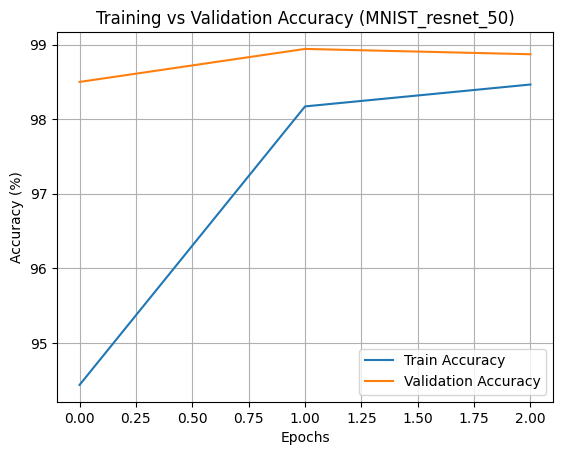

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy (MNIST_resnet_50)")
plt.legend()
plt.grid(True)
plt.show()

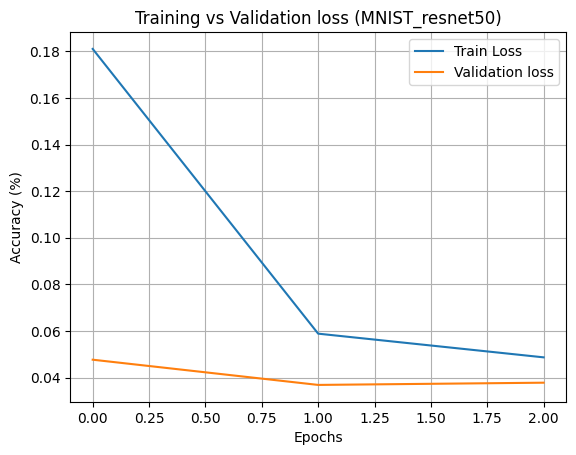

In [18]:


plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation loss (MNIST_resnet50)")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
batch_size = 32
optimizer_name = "SGD"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 79.07% | Val Acc: 95.43%


Epoch [2/3] | Train Acc: 97.26% | Val Acc: 98.47%


Epoch [3/3] | Train Acc: 98.50% | Val Acc: 98.70%
TEST ACCURACY: 98.73571428571428
Model saved at: mnist_resnet50_bs32_SGD_lr0.001.pth


In [36]:
batch_size = 32
optimizer_name = "SGD"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 34.94% | Val Acc: 51.70%


Epoch [2/3] | Train Acc: 62.99% | Val Acc: 77.24%


Epoch [3/3] | Train Acc: 82.03% | Val Acc: 90.36%
TEST ACCURACY: 90.45
Model saved at: mnist_resnet50_bs32_SGD_lr0.0001.pth


In [21]:
batch_size = 32
optimizer_name = "Adam"
learning_rate = 0.0001
epochs = 3
pin_memory = True
model_name = "resnet50"

train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 93.65% | Val Acc: 98.67%


Epoch [2/3] | Train Acc: 98.48% | Val Acc: 98.44%


Epoch [3/3] | Train Acc: 98.80% | Val Acc: 99.19%
TEST ACCURACY: 99.09285714285714
Model saved at: mnist_resnet50_bs32_Adam_lr0.0001.pth


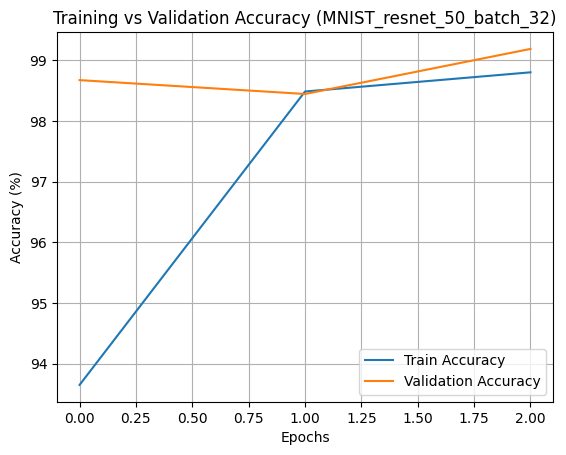

In [22]:
plt.figure()
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy (MNIST_resnet_50_batch_32)")
plt.legend()
plt.grid(True)
plt.show()

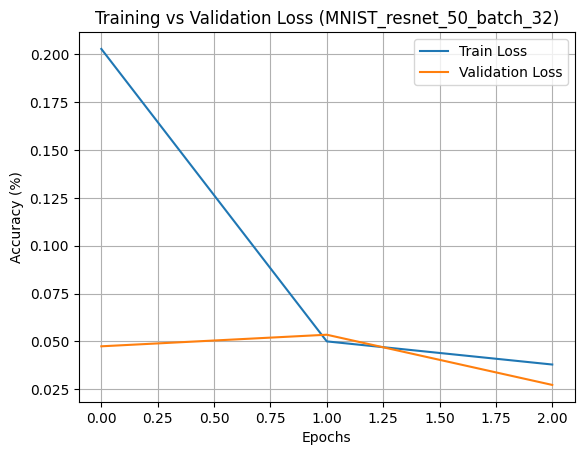

In [23]:
plt.figure()
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Loss (MNIST_resnet_50_batch_32)")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
batch_size = 32
optimizer_name = "Adam"
learning_rate = 0.001
epochs = 3
pin_memory = True
model_name = "resnet50"


train_loader, val_loader, test_loader = get_loaders(batch_size, pin_memory)
model = get_model(model_name)

criterion = nn.CrossEntropyLoss()

if optimizer_name == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
else:
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

test_acc = test(model, test_loader)
print("TEST ACCURACY:", test_acc)



model_path = f"mnist_{model_name}_bs{batch_size}_{optimizer_name}_lr{learning_rate}.pth"
torch.save(model.state_dict(), model_path)
print("Model saved at:", model_path)


  0%|          | 0/1532 [00:00<?, ?it/s]/tmp/ipykernel_55/2533370566.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_55/2533370566.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch [1/3] | Train Acc: 94.48% | Val Acc: 97.40%


Epoch [2/3] | Train Acc: 97.56% | Val Acc: 98.71%


Epoch [3/3] | Train Acc: 98.09% | Val Acc: 97.86%
TEST ACCURACY: 97.57857142857142
Model saved at: mnist_resnet50_bs32_Adam_lr0.001.pth


1b

In [16]:
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [17]:
def dataset_to_numpy(dataset):
    X, y = [], []
    for img, label in dataset:
        X.append(img.view(-1).numpy())   # flatten image
        y.append(label)
    return np.array(X), np.array(y)


In [ ]:
X_train_mnist, y_train_mnist = dataset_to_numpy(mnist_train)
X_test_mnist,  y_test_mnist  = dataset_to_numpy(mnist_test)

print("MNIST Train shape:", X_train_mnist.shape)
print("MNIST Test shape:", X_test_mnist.shape)


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [2]:
transform = transforms.ToTensor()

mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST('./data', train=False, download=True, transform=transform)

fashion_train = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
fashion_test  = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)


100%|██████████| 26.4M/26.4M [00:01<00:00, 14.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 269kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.00MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.4MB/s]


In [3]:
def dataset_to_numpy(dataset, max_samples=None):
    X, y = [], []
    for i, (img, label) in enumerate(dataset):
        if max_samples and i >= max_samples:
            break
        X.append(img.view(-1).numpy())  # 28x28 → 784
        y.append(label)
    return np.array(X), np.array(y)


In [4]:
X_mnist_train, y_mnist_train = dataset_to_numpy(mnist_train)
X_mnist_test,  y_mnist_test  = dataset_to_numpy(mnist_test)


In [10]:

X_fashion_train, y_fashion_train = dataset_to_numpy(fashion_train)
X_fashion_test, y_fashion_test  = dataset_to_numpy(fashion_test)

In [6]:
print("MNIST Train shape:", X_mnist_train.shape)
print("MNIST Test shape:", X_mnist_test.shape)

MNIST Train shape: (60000, 784)
MNIST Test shape: (10000, 784)


In [11]:
print("MNIST Train shape:", X_fashion_train.shape)
print("MNIST Test shape:", X_fashion_test.shape)

MNIST Train shape: (60000, 784)
MNIST Test shape: (10000, 784)


In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

svm_mnist_rbf = SVC(kernel="rbf", C=1.0)

start_time = time.time()
svm_mnist_rbf.fit(X_mnist_train, y_mnist_train)
end_time = time.time()

train_time_ms = (end_time - start_time) * 1000
y_pred = svm_mnist_rbf.predict(X_mnist_test)
test_acc = accuracy_score(y_mnist_test, y_pred) * 100

print("MNIST | RBF")
print("Test Accuracy (%):", test_acc)
print("Training Time (ms):", train_time_ms)


MNIST | RBF
Test Accuracy (%): 97.92
Training Time (ms): 204594.83981132507


In [8]:
svm_mnist_poly = SVC(kernel="poly", degree=3, C=1.0)

start_time = time.time()
svm_mnist_poly.fit(X_mnist_train, y_mnist_train)
end_time = time.time()

train_time_ms = (end_time - start_time) * 1000
y_pred = svm_mnist_poly.predict(X_mnist_test)
test_acc = accuracy_score(y_mnist_test, y_pred) * 100

print("MNIST | Polynomial")
print("Test Accuracy (%):", test_acc)
print("Training Time (ms):", train_time_ms)


MNIST | Polynomial
Test Accuracy (%): 97.71
Training Time (ms): 212713.63162994385


In [12]:
svm_fashion_rbf = SVC(kernel="rbf", C=1.0)

start_time = time.time()
svm_fashion_rbf.fit(X_fashion_train, y_fashion_train)
end_time = time.time()

train_time_ms = (end_time - start_time) * 1000
y_pred = svm_fashion_rbf.predict(X_fashion_test)
test_acc = accuracy_score(y_fashion_test, y_pred) * 100

print("FashionMNIST | RBF")
print("Test Accuracy (%):", test_acc)
print("Training Time (ms):", train_time_ms)


FashionMNIST | RBF
Test Accuracy (%): 88.29
Training Time (ms): 283054.48269844055


In [13]:
svm_fashion_poly = SVC(kernel="poly", degree=3, C=1.0)

start_time = time.time()
svm_fashion_poly.fit(X_fashion_train, y_fashion_train)
end_time = time.time()

train_time_ms = (end_time - start_time) * 1000
y_pred = svm_fashion_poly.predict(X_fashion_test)
test_acc = accuracy_score(y_fashion_test, y_pred) * 100

print("FashionMNIST | Polynomial")
print("Test Accuracy (%):", test_acc)
print("Training Time (ms):", train_time_ms)


FashionMNIST | Polynomial
Test Accuracy (%): 86.3
Training Time (ms): 339395.1733112335


Q2 final


In [3]:
pip install torch torchvision fvcore tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=4a69c894a299ca788dfa205832db2c9f625a4c91183404420946ec65e953bb52
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=0b54f1ec90ffb9fbf2dc2cb0cb910d75894621b272108fea7d21ff9bbb88b02e
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time
from tqdm import tqdm

# FLOPs
from fvcore.nn import FlopCountAnalysis

# Speed optimizations
torch.backends.cudnn.benchmark = True


In [5]:
def get_device(use_gpu=True):
    if use_gpu and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


In [6]:
def get_dataloaders(batch_size=16):
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_set = torchvision.datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )

    test_set = torchvision.datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    test_loader = torch.utils.data.DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    return train_loader, test_loader


In [7]:
def get_model(model_name):
    if model_name == "resnet18":
        model = torchvision.models.resnet18(weights=None)
    elif model_name == "resnet32":
        model = torchvision.models.resnet34(weights=None)  # commonly used as ResNet-32
    elif model_name == "resnet50":
        model = torchvision.models.resnet50(weights=None)
    else:
        raise ValueError("Invalid model")

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model


In [8]:
def get_optimizer(optimizer_name, model, lr=0.001):
    if optimizer_name == "SGD":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "Adam":
        return optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("Invalid optimizer")


In [9]:
def calculate_flops(model, device):
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    flops = FlopCountAnalysis(model, dummy_input)
    return flops.total()


In [10]:
def train_model(model, train_loader, optimizer, device, epochs=1):
    model.train()
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler()

    start_time = time.time()

    for _ in range(epochs):
        for images, labels in tqdm(train_loader, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=device.type=="cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

    torch.cuda.synchronize() if device.type == "cuda" else None
    total_time_ms = (time.time() - start_time) * 1000

    return total_time_ms


In [11]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


In [13]:
def run_experiment(
    compute="CPU",
    model_name="resnet18",
    optimizer_name="SGD",
    batch_size=16,
    lr=0.001
):
    device = get_device(use_gpu=(compute=="GPU"))
    train_loader, test_loader = get_dataloaders(batch_size)

    model = get_model(model_name).to(device)
    optimizer = get_optimizer(optimizer_name, model, lr)

    flops = calculate_flops(model, device)
    train_time = train_model(model, train_loader, optimizer, device)
    accuracy = evaluate_model(model, test_loader, device)

    return accuracy, train_time, flops


In [89]:
configs = [
    ("CPU", "resnet18", "SGD"),
    ("CPU", "resnet18", "Adam"),
    ("GPU", "resnet18", "SGD"),
    ("GPU", "resnet18", "Adam"),
]

for cfg in configs:
    acc, time_ms, flops = run_experiment(*cfg)
    print(cfg, f"Acc={acc:.2f}%", f"Time={time_ms:.1f}ms", f"FLOPs={flops:.2e}")


Unsupported operator aten::add_ encountered 28 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
  0%|          | 0/3750 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('CPU', 'resnet18', 'SGD') Acc=87.66% Time=5465133.9ms FLOPs=1.83e+09


Unsupported operator aten::add_ encountered 28 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
  0%|          | 0/3750 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('CPU', 'resnet18', 'Adam') Acc=87.94% Time=5157049.8ms FLOPs=1.83e+09


Unsupported operator aten::add_ encountered 28 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
  0%|          | 0/3750 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


KeyboardInterrupt: 

In [14]:
configs = [
    
    ("GPU", "resnet18", "SGD"),
    ("GPU", "resnet18", "Adam"),
]

for cfg in configs:
    acc, time_ms, flops = run_experiment(*cfg)
    print(cfg, f"Acc={acc:.2f}%", f"Time={time_ms:.1f}ms", f"FLOPs={flops:.2e}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.50MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]
Unsupported operator aten::add_ encountered 28 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('GPU', 'resnet18', 'SGD') Acc=88.60% Time=110018.2ms FLOPs=1.83e+09


Unsupported operator aten::add_ encountered 28 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('GPU', 'resnet18', 'Adam') Acc=86.00% Time=108764.6ms FLOPs=1.83e+09


In [15]:
configs = [
   
    ("GPU", "resnet50", "SGD"),
    ("GPU", "resnet50", "Adam"),
]

for cfg in configs:
    acc, time_ms, flops = run_experiment(*cfg)
    print(cfg, f"Acc={acc:.2f}%", f"Time={time_ms:.1f}ms", f"FLOPs={flops:.2e}")

Unsupported operator aten::add_ encountered 69 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('GPU', 'resnet50', 'SGD') Acc=84.97% Time=260172.1ms FLOPs=4.14e+09


Unsupported operator aten::add_ encountered 69 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('GPU', 'resnet50', 'Adam') Acc=83.85% Time=272061.4ms FLOPs=4.14e+09


In [16]:
configs = [
    ("CPU", "resnet50", "SGD"),
    ("CPU", "resnet50", "Adam"),
    
]

for cfg in configs:
    acc, time_ms, flops = run_experiment(*cfg)
    print(cfg, f"Acc={acc:.2f}%", f"Time={time_ms:.1f}ms", f"FLOPs={flops:.2e}")

Unsupported operator aten::add_ encountered 69 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('CPU', 'resnet50', 'SGD') Acc=81.89% Time=11694821.0ms FLOPs=4.14e+09


Unsupported operator aten::add_ encountered 69 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
/tmp/ipykernel_55/625443637.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/3750 [00:00<?, ?it/s]/tmp/ipykernel_55/625443637.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type=="cuda"):


('CPU', 'resnet50', 'Adam') Acc=87.17% Time=11891301.6ms FLOPs=4.14e+09


In [72]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class ResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_planes = 16

        self.conv1 = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = self._make_layer(block, 16, num_blocks[0], 1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], 2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], 2)

        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, out.size(3))
        return self.fc(out.view(out.size(0), -1))


def resnet32(num_classes=10):
    return ResNetCIFAR(BasicBlock, [5, 5, 5], num_classes)
